In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('Mall_Customers.csv')

In [3]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


# Basic checks

In [4]:
data.shape

(200, 5)

In [5]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
data.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
data.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [9]:
num_col = data.select_dtypes(include=['int64','float64'])
num_col

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40
...,...,...,...,...
195,196,35,120,79
196,197,45,126,28
197,198,32,126,74
198,199,32,137,18


In [10]:
cat_col = data.select_dtypes(include='object')
cat_col

,Gender
0,Male
1,Male
2,Female
3,Female
4,Female
...,...
195,Female
196,Female
197,Male
198,Male


In [11]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [12]:
# check for missing values
data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [13]:
# check for duplicates
data.duplicated().sum()

np.int64(0)

#EDA

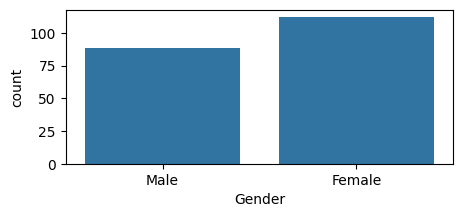

In [16]:
# Visualise the count of Male and female
plt.figure(figsize=(5,2))
sns.countplot(data,x='Gender')
plt.show()

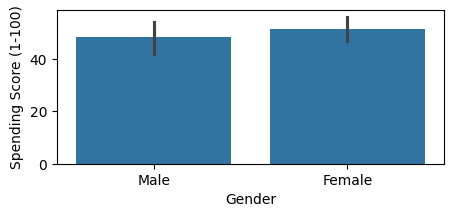

In [17]:
# Find Average Spending score with male and female
plt.figure(figsize=(5,2))
sns.barplot(data,x='Gender',y='Spending Score (1-100)')
plt.show()

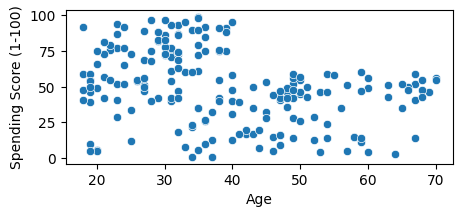

In [18]:
# find relationship between  age and Spending score
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Age',y='Spending Score (1-100)')
plt.show()

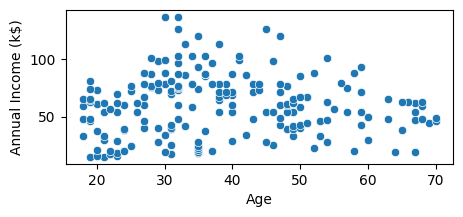

In [20]:
# find relationship between age and Annual Income (k$)
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Age',y='Annual Income (k$)')
plt.show()

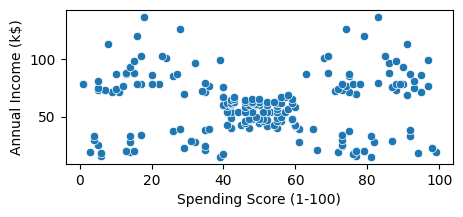

In [21]:
# find relationship between Annual Income (k$) and	Spending Score (1-100)
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Spending Score (1-100)',y='Annual Income (k$)')
plt.show()

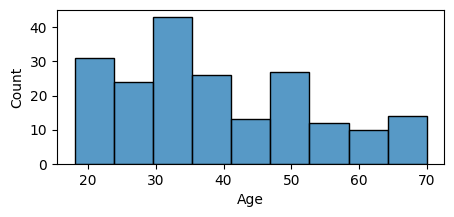

In [22]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='Age')
plt.show()

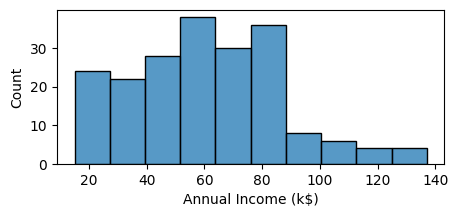

In [23]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='Annual Income (k$)')
plt.show()

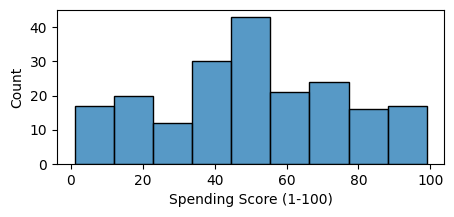

In [24]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='Spending Score (1-100)')
plt.show()

**Encoding**

In [26]:
# gender --> male , female
data = pd.get_dummies(data,columns=['Gender'],dtype='int')

In [28]:
# Scaling ;Age	Annual Income (k$)	Spending Score (1-100)
from sklearn.preprocessing import StandardScaler
model = StandardScaler()
data[['Age']]=model.fit_transform(data[['Age']])
data[['Annual Income (k$)']]=model.fit_transform(data[['Annual Income (k$)']])
data[['Spending Score (1-100)']]=model.fit_transform(data[['Spending Score (1-100)']])



In [29]:
data

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male
0,1,-1.424569,-1.738999,-0.434801,0,1
1,2,-1.281035,-1.738999,1.195704,0,1
2,3,-1.352802,-1.700830,-1.715913,1,0
3,4,-1.137502,-1.700830,1.040418,1,0
4,5,-0.563369,-1.662660,-0.395980,1,0
...,...,...,...,...,...,...
195,196,-0.276302,2.268791,1.118061,1,0
196,197,0.441365,2.497807,-0.861839,1,0
197,198,-0.491602,2.497807,0.923953,0,1
198,199,-0.491602,2.917671,-1.250054,0,1
